# 2.4 - Visualizing Relationships Between Groups

This notebook uses the `titanic_passengers.csv` dataset to explore differences in passenger age across ticket classes.


## 1. Read in the dataset

Import Pandas, Matplotlib, and Seaborn, then load the Titanic passenger data into a DataFrame.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("assets/titanic_passengers.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Calculate mean and median age by passenger class

This helps compare the center of the age distribution across the three ticket classes.


In [3]:
age_stats = df.groupby("Pclass")["Age"].agg(["mean", "median", "count"])
age_stats

,mean,median,count
Pclass,,,
1,38.233441,37.0,186
2,29.877630,29.0,173
3,25.140620,24.0,355


### Answer

Yes, I do suspect there are age differences between the passenger classes. Based on the summary statistics, 1st class passengers tend to be the oldest, 2nd class passengers are in the middle, and 3rd class passengers tend to be the youngest.


## 3. Plot an overlaid histogram of age by passenger class

This makes it easier to compare the overall shapes of the distributions and see where the groups overlap.


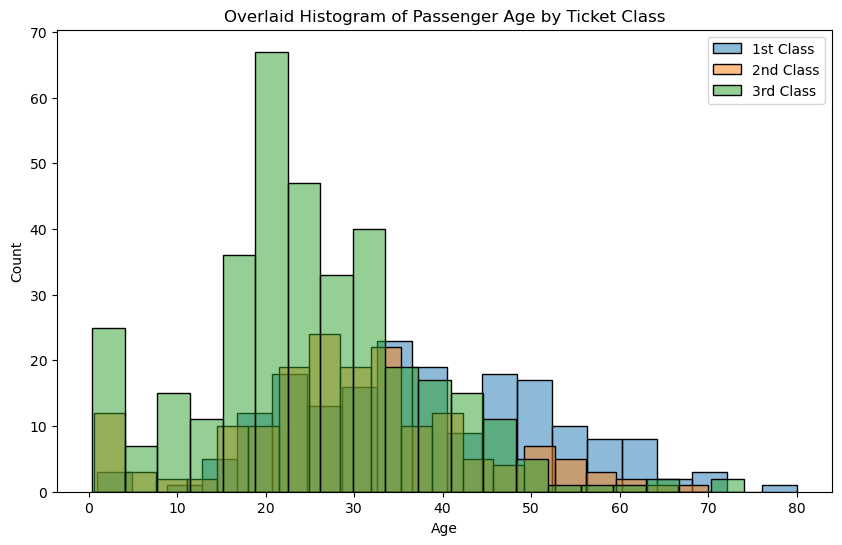

In [4]:
plt.figure(figsize=(10, 6))

sns.histplot(df[df["Pclass"] == 1]["Age"].dropna(), bins=20, alpha=0.5, label="1st Class")
sns.histplot(df[df["Pclass"] == 2]["Age"].dropna(), bins=20, alpha=0.5, label="2nd Class")
sns.histplot(df[df["Pclass"] == 3]["Age"].dropna(), bins=20, alpha=0.5, label="3rd Class")

plt.title("Overlaid Histogram of Passenger Age by Ticket Class")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend()
plt.show()

## 4. Plot side-by-side boxplots of age for each passenger class

Because `Pclass` is numeric, I first create a string version of the feature so the boxplots display more clearly as separate categories.


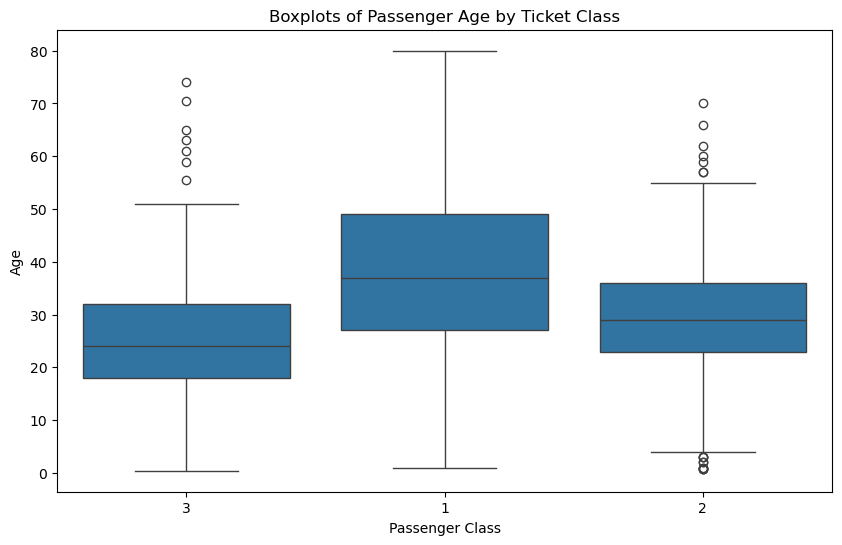

In [5]:
df["Pclass_cat"] = df["Pclass"].astype("str")

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Pclass_cat", y="Age")

plt.title("Boxplots of Passenger Age by Ticket Class")
plt.xlabel("Passenger Class")
plt.ylabel("Age")
plt.show()

## 5. Comparing what each graph shows best

**One feature that is easier to observe from the overlaid histogram:**  
The histogram makes it easier to see the overall shape of the distributions and where the different passenger classes overlap.

**One feature that is easiest to see from the side-by-side boxplots:**  
The boxplots make it easier to compare the median age and the interquartile range (IQR) for each passenger class.


## 6. Describe the differences in center, shape, and spread

The center of the age distribution is highest for 1st class, lower for 2nd class, and lowest for 3rd class. This shows that passengers in 1st class were generally older, while passengers in 3rd class were generally younger.

In terms of shape, the overlaid histogram shows that all three classes have most passengers concentrated in younger to middle adult ages, but 3rd class has more younger passengers overall. The distributions also overlap, although the center shifts upward as class increases.

For spread, 1st class appears to have a wider range of ages and a somewhat larger IQR than 3rd class, showing more variation. The boxplots also make it easy to compare the median values and see that age tends to increase from 3rd class to 1st class.


In [6]:
# Optional: additional descriptive statistics
df.groupby("Pclass")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Pclass,,,,,,,,
1,186.0,38.233441,14.802856,0.92,27.0,37.0,49.0,80.0
2,173.0,29.877630,14.001077,0.67,23.0,29.0,36.0,70.0
3,355.0,25.140620,12.495398,0.42,18.0,24.0,32.0,74.0
